#To What Extent Do More Airbnb Reviews Reduce Pricing Inefficiency? Evidence from NYC Listings

 # Project 1

## 1.1 Introduction


Airbnb hosts set prices in markets where listings are differentiated by quality, location, and host characteristics, and where information is imperfect for both guests (about quality and trustworthiness) and hosts (about the “right” price). A large empirical literature uses hedonic pricing frameworks to show that Airbnb prices reflect structural listing characteristics, neighbourhood attributes, and broader spatial market structure, while also emphasizing that prices are not formed independently across space. In particular, spatial econometric work finds that nearby listings’ prices move together and that modelling spatial dependence is important for understanding short-term rental pricing (Gyódi & Nawaro, 2021; Boto-García et al., 2021). Recent studies further reinforce this point by showing that Airbnb prices are shaped by both property/service attributes and local-area conditions, including built-environment and transport-related factors, and that these effects can vary substantially across space and across the price distribution (Bernardi & Guidolin, 2023; Zhao, 2023).


A second strand of research emphasizes the role of platform information and reputation mechanisms. Reviews and ratings can reduce information asymmetries, and existing evidence shows that review-based measures, particularly written sentiment-based content, are meaningfully related to Airbnb prices (Lawani et al., 2019; Lin & Yang, 2024). More broadly, Airbnb prices and guest decisions also respond to other trust signals embedded in the platform. For example, Ert, Fleischer, and Magen (2016) demonstrate that hosts perceived as more trustworthy based on their photos charge higher prices and are more likely to be chosen, while standard review scores may become less informative when ratings are highly compressed. Related work on Airbnb screening behavior also highlights that platform design affects how hosts manage uncertainty. Mayya et al. (2021) show that hosts can trade off stricter screening for higher occupancy through Instant Book, illustrating how market outcomes depend on the interaction between platform mechanisms and information asymmetry.


A third strand of literature focuses on host concentration, professionalization, and market competition. Research on market structure shows that while city-level listing concentration may not always have a large direct effect on prices, hosts with larger listing shares can exert greater influence over pricing and compete differently from casual hosts (Bárcena-Martín, Benítez-Aurioles, & Pérez-Moreno, 2023). Similarly, Boto-García et al. (2021) find that spatial price mimicking differs between multi-host and single-host listings, while Abrate, Sainaghi, and Mauri (2022) show that professional hosts adopt more dynamic pricing strategies and display greater price variability than individual hosts. NYC-specific evidence also points in this direction: Voltes-Dorta (2025) finds that price competition among short-term Airbnb listings is weakened by the presence of multi-listing hosts following Local Law 18, suggesting that host concentration can shape local pricing dynamics even within the same city.


Building on these insights, this project reframes Airbnb pricing as a pricing-efficiency and learning question rather than simply asking what predicts higher prices. Existing studies show that prices depend on a multitude of factors, including listing attributes, neighbourhood effects, spatial interdependence, reputation signals, and host structure, but say less about whether ongoing market feedback helps hosts price more efficiently relative to close local comparables. Motivated especially by Lin and Yang’s (2024) emphasis on reviews as a mechanism for iterative price adjustment, I test whether review intensity (reviews_per_month) is associated with lower pricing inefficiency, measured as the absolute deviation from the neighbourhood × room_type benchmark price, and to what extent that relationship varies with the clarity of local market signals, proxied by comparable listing density. Overall, the evidence suggests that listings with higher review intensity tend to exhibit lower absolute mispricing, but that this relationship, while statistically significant, is economically modest and varies across market-density conditions.


Data: The primary dataset is the NYC Airbnb listings dataset, where the unit of observation is the individual listing. It contains listing prices, location identifiers (neighbourhood and borough), property type information, and review activity measures such as reviews_per_month. To account for broader safety differences across boroughs, I merge in 2019 NYPD complaint counts aggregated to the borough × law-category level and construct borough-level crime measures that are used as coarse location controls. I also merge in MTA subway-station data and construct a transit-access measure based on each listing’s distance to the nearest subway station. For the spatial analysis, I assign listings to MODZCTAs (Modified ZIP Code Tabulation Areas), which are NYC-specific ZIP-like geographic units used for mapping and public-health reporting. This allows the map section to aggregate listing-level outcomes to a smaller and more informative spatial unit than the borough level.

Research question: To what extent is review intensity (reviews_per_month) associated with lower pricing inefficiency (absolute deviation from the neighbourhood × room_type benchmark price), and is this relationship stronger in markets with clearer price signals (higher comparable listing density)?


To operationalize pricing efficiency, I construct an outcome measure of pricing inefficiency defined as the absolute deviation between a listing’s price and the typical price for similar listings in the same local market segment:


Variables (X, Y, Z):


Y (Outcome: pricing inefficiency).
mispricing_abs = |price − median price within (neighbourhood, room_type)|.
This measures how far a listing’s price deviates from the typical price of close comparables. The absolute value captures magnitude of inefficiency (over- or under-pricing), and the median benchmark is robust to outliers and extreme listings. Using (neighbourhood, room_type) defines a realistic comparable set based on the two most salient market segments on Airbnb.


X (Main explanatory: review intensity / feedback flow).
reviews_per_month.
Interpreted as the rate of incoming feedback/transactions: more review activity means more opportunities for a host to update beliefs about demand and willingness-to-pay, which should reduce persistent deviations from the local benchmark.


Z (Mechanism proxy: clarity of local price signals):
Log_comp_density = log(1 + number of listings in the same (neighbourhood, room_type) cell)
When there are more comparable listings, the local “going rate” is easier to infer and less noisy; if learning is the mechanism, the negative association between reviews_per_month and mispricing_abs should be stronger when log_comp_density is higher.
Additional X variables:
minimum_nights and availability_365: capture booking frictions and usage patterns that can mechanically relate to review flow and pricing behavior.
number_of_reviews: captures accumulated reputation/tenure separately from the rate of new feedback.
calculated_host_listings_count: proxies host scale/market power and professionalization, which may relate to both pricing strategies and review activity.
borough-level crime measures (external merge): included to account for broad safety differences across boroughs that can shift baseline demand and prices; treated as a coarse location control (not a causal listing-level safety measure).
nearest_subway_km/log_nearest_subway_km: proxy transit accessibility. Listings closer to subway access may face different demand conditions, neighbourhood desirability, and pricing environments. I use the logged distance measure in the regressions as an additional location/accessibility control, while the level measure is used in maps and summary statistics.

In [215]:
#Setup cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys


In [216]:
df = pd.read_csv("../AB_NYC_2019.csv") 

## 1.2 Data Cleaning/Loading

In [217]:
# Make a working copy
df = df.copy()

# Ensure numeric price 
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Drop rows missing key fields for definitions
df = df.dropna(subset=["price", "neighbourhood", "room_type"])

# Trim extreme values
df = df[df["price"].between(10, 1000)]


**Create a Benchmark Price**:

In [218]:
bench = (
    df.groupby(["neighbourhood", "room_type"])["price"]
      .median()
      .rename("bench_price")
)

df = df.join(bench, on=["neighbourhood", "room_type"])
df["mispricing_abs"] = (df["price"] - df["bench_price"]).abs()

Create Z variable/mechanism:

In [219]:
density = (
    df.groupby(["neighbourhood", "room_type"])
      .size()
      .rename("comp_density")
)

df = df.join(density, on=["neighbourhood", "room_type"])
df["log_comp_density"] = np.log1p(df["comp_density"])

**Merge in Crime**:

In [220]:
crime = pd.read_csv("../crime_2019_boro_lawcat.csv")  


In [ ]:
crime_piv = (
    crime.pivot(index="boro_nm", columns="law_cat_cd", values="n")
         .reset_index()
)

crime_piv.columns.name = None  

# rename to clearer variable names
crime_piv = crime_piv.rename(columns={
    "boro_nm": "neighbourhood_group",
    "FELONY": "crime_felony_2019",
    "MISDEMEANOR": "crime_misd_2019",
    "VIOLATION": "crime_viol_2019"
})

# map borough names to match airbnb neighbourhood_group
boro_map = {
    "MANHATTAN": "Manhattan",
    "BRONX": "Bronx",
    "BROOKLYN": "Brooklyn",
    "QUEENS": "Queens",
    "STATEN ISLAND": "Staten Island"
}
crime_piv["neighbourhood_group"] = crime_piv["neighbourhood_group"].map(boro_map)

crime_piv


In [222]:
df = df.merge(crime_piv, on="neighbourhood_group", how="left")

df[["crime_felony_2019","crime_misd_2019","crime_viol_2019"]].isna().mean()
df["crime_total_2019"] = df["crime_felony_2019"] + df["crime_misd_2019"] + df["crime_viol_2019"]


**Merge in transit**:

In [223]:
import pandas as pd
import numpy as np
import geopandas as gpd

# Load subway data
subway = pd.read_csv("../MTA_Subway_Stations.csv")
subway.columns = subway.columns.str.strip()
df.columns = df.columns.str.strip()

# Convert cleaned Airbnb sample to GeoDataFrame
airbnb_gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# Convert subway stations to GeoDataFrame
subway_gdf = gpd.GeoDataFrame(
    subway,
    geometry=gpd.points_from_xy(subway["GTFS Longitude"], subway["GTFS Latitude"]),
    crs="EPSG:4326"
)

# Reproject both to NYC / Long Island feet-based CRS for distance calculation
airbnb_gdf = airbnb_gdf.to_crs("EPSG:2263")
subway_gdf = subway_gdf.to_crs("EPSG:2263")

# Keep only needed subway columns
subway_gdf = subway_gdf[["Stop Name", "Borough", "Line", "geometry"]]

# Find nearest subway station for each Airbnb listing
airbnb_nearest = gpd.sjoin_nearest(
    airbnb_gdf,
    subway_gdf,
    how="left",
    distance_col="nearest_subway_ft"
)

# Remove any duplicate listing ids created by nearest-match ties
airbnb_nearest = (
    airbnb_nearest
    .sort_values("id")
    .drop_duplicates(subset="id", keep="first")
    .copy()
)

# Convert feet to kilometers
airbnb_nearest["nearest_subway_km"] = airbnb_nearest["nearest_subway_ft"] * 0.0003048

# Logged version for later regressions
airbnb_nearest["log_nearest_subway_km"] = np.log1p(airbnb_nearest["nearest_subway_km"])

# Keep only the new transit variables plus listing id
transit = airbnb_nearest[["id", "nearest_subway_km", "log_nearest_subway_km"]].copy()

# Make sure transit itself is one row per listing
transit = transit.sort_values("id").drop_duplicates(subset="id", keep="first").copy()

# Drop old transit columns first if they already exist
df = df.drop(columns=["nearest_subway_km", "log_nearest_subway_km"], errors="ignore")

# Merge transit back into main dataframe
df = df.merge(transit, on="id", how="left")

# Make it one row per listing
df = df.sort_values("id").drop_duplicates(subset="id", keep="first").copy()




## 1.3 Summary Statistics Tables

In [224]:
from IPython.display import display

vars_main = [
    "mispricing_abs",
    "reviews_per_month",
    "log_comp_density",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "calculated_host_listings_count",
    "crime_total_2019",
    "nearest_subway_km"
]

label_map = {
    "mispricing_abs": "Absolute mispricing",
    "reviews_per_month": "Reviews/month",
    "log_comp_density": "Log comp. density",
    "minimum_nights": "Minimum nights",
    "availability_365": "Availability 365",
    "number_of_reviews": "Number of reviews",
    "calculated_host_listings_count": "Host listings count",
    "crime_total_2019": "Crime total (2019)",
    "nearest_subway_km": "Distance to subway (km)"
}

df_summary = df[vars_main].dropna().copy()

table1 = df_summary.describe().T[["count", "mean", "std", "min", "max"]]
table1 = table1.rename(columns={
    "count": "N",
    "mean": "Mean",
    "std": "Std. Dev.",
    "min": "Min",
    "max": "Max"
})

table1.index = table1.index.map(label_map)
table1 = table1.round(3)
table1["N"] = table1["N"].astype(int)

display(
    table1.style
    .format({
        "N": "{:d}",
        "Mean": "{:.3f}",
        "Std. Dev.": "{:.3f}",
        "Min": "{:.3f}",
        "Max": "{:.3f}",
    })
    .set_caption("Table 1. Summary Statistics")
)

print("Summary-table N:", len(df_summary))


,N,Mean,Std. Dev.,Min,Max
Absolute mispricing,38726,45.761,77.174,0.000,925.000
Reviews/month,38726,1.375,1.682,0.010,58.500
Log comp. density,38726,6.035,1.392,0.693,7.616
Minimum nights,38726,5.845,17.286,1.000,1250.000
Availability 365,38726,114.601,129.399,0.000,365.000
Number of reviews,38726,29.337,48.235,1.000,629.000
Host listings count,38726,5.172,26.334,1.000,327.000
Crime total (2019),38726,118790.520,15859.839,18913.000,132103.000
Distance to subway (km),38726,0.437,0.577,0.001,7.903


Summary-table N: 38726


Table 1 reports summary statistics for the main variables used in the analysis. Most listings have low review intensity (reviews_per_month concentrated near zero), and the outcome variable (mispricing_abs) shows a strong right tail, indicating a small number of listings with very large deviations from the neighbourhood × room_type benchmark. Overall, this motivates using visualizations (and binning) to summarize patterns rather than relying on raw scatter alone.


In [225]:
z = df_summary["log_comp_density"]
df_summary["Z_group"] = np.where(z <= z.median(), "Low Z", "High Z")

label_map = {
    "mispricing_abs": "Absolute mispricing",
    "reviews_per_month": "Reviews/month",
    "log_comp_density": "Log comp. density",
    "minimum_nights": "Minimum nights",
    "availability_365": "Availability 365",
    "number_of_reviews": "Number of reviews",
    "calculated_host_listings_count": "Host listings count",
    "crime_total_2019": "Crime total (2019)",
    "nearest_subway_km": "Distance to subway (km)"
}

def make_table(sub_df):
    t = sub_df[vars_main].describe().T[["count", "mean", "std", "min", "max"]]
    t = t.rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std. Dev.",
        "min": "Min",
        "max": "Max"
    })
    t.index = t.index.map(label_map)
    t = t.round(3)
    t["N"] = t["N"].astype(int)
    return t

table2_low = make_table(df_summary[df_summary["Z_group"] == "Low Z"])
table2_high = make_table(df_summary[df_summary["Z_group"] == "High Z"])

display(
    table2_low.style
    .format({
        "N": "{:d}",
        "Mean": "{:.3f}",
        "Std. Dev.": "{:.3f}",
        "Min": "{:.3f}",
        "Max": "{:.3f}",
    })
    .set_caption("Table 2a. Summary Statistics (Low Z)")
)

display(
    table2_high.style
    .format({
        "N": "{:d}",
        "Mean": "{:.3f}",
        "Std. Dev.": "{:.3f}",
        "Min": "{:.3f}",
        "Max": "{:.3f}",
    })
    .set_caption("Table 2b. Summary Statistics (High Z)")
)



,N,Mean,Std. Dev.,Min,Max
Absolute mispricing,19542,42.402,76.242,0.000,921.000
Reviews/month,19542,1.484,1.809,0.010,58.500
Log comp. density,19542,4.961,1.165,0.693,6.370
Minimum nights,19542,5.387,16.915,1.000,1250.000
Availability 365,19542,125.781,132.670,0.000,365.000
Number of reviews,19542,29.855,48.160,1.000,629.000
Host listings count,19542,6.562,34.488,1.000,327.000
Crime total (2019),19542,113496.553,19413.960,18913.000,132103.000
Distance to subway (km),19542,0.532,0.780,0.002,7.903


,N,Mean,Std. Dev.,Min,Max
Absolute mispricing,19184,49.182,77.965,0.000,925.000
Reviews/month,19184,1.264,1.533,0.010,14.000
Log comp. density,19184,7.129,0.399,6.433,7.616
Minimum nights,19184,6.312,17.643,1.000,999.000
Availability 365,19184,103.213,124.960,0.000,365.000
Number of reviews,19184,28.809,48.308,1.000,607.000
Host listings count,19184,3.755,13.580,1.000,327.000
Crime total (2019),19184,124183.280,8136.744,115824.000,132103.000
Distance to subway (km),19184,0.339,0.183,0.001,1.153


Tables 2a–2b split the sample by the competition proxy (Z = log_comp_density), where “High Z” represents neighbourhood × room_type cells with more comparable listings (clearer local price signals). Comparing means across the two groups provides an initial check for whether mispricing levels and review intensity differ systematically across more vs less information-rich markets.


## 1.4 Plots and Figures

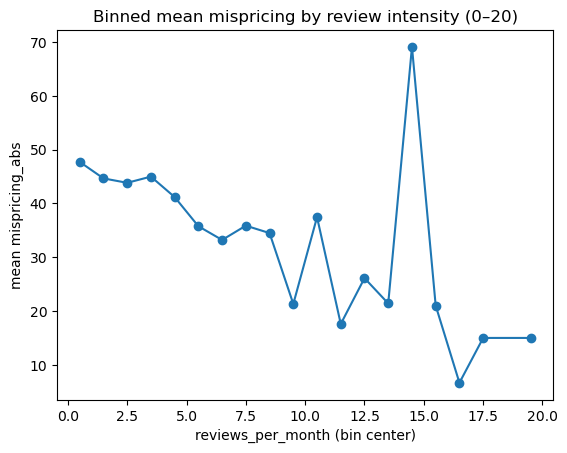

In [226]:
import numpy as np
import matplotlib.pyplot as plt
tmp = df[["reviews_per_month","mispricing_abs"]].dropna().copy()

tmp["rpm_bin"] = pd.cut(tmp["reviews_per_month"], bins=np.arange(0, 21, 1), right=False)
bin_means = tmp.groupby("rpm_bin", observed=True)["mispricing_abs"].mean()
x = [b.left + 0.5 for b in bin_means.index] 

plt.plot(x, bin_means.values, marker="o")
plt.title("Binned mean mispricing by review intensity (0–20)")
plt.xlabel("reviews_per_month (bin center)")
plt.ylabel("mean mispricing_abs")
plt.show()

Figure 1 shows mean mispricing_abs by 1-unit bins of reviews_per_month (0–20). The binned trend generally declines as review intensity increases, which is consistent with a “learning/pricing-efficiency” interpretation (more review activity is associated with smaller deviations from the benchmark). Isolated spikes at higher bins likely reflect small cell sizes (few listings with very high reviews_per_month).


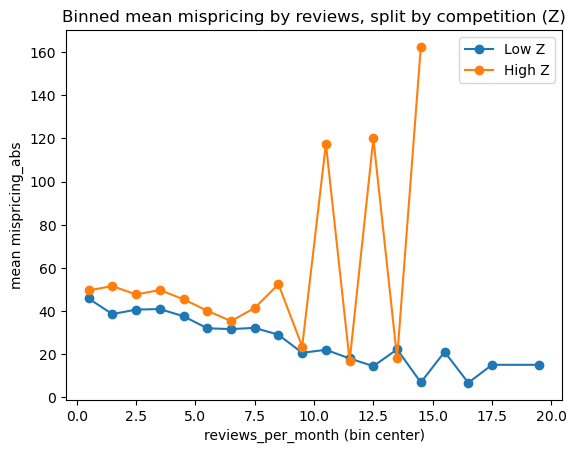

In [227]:
tmp = df[["reviews_per_month","mispricing_abs","log_comp_density"]].dropna().copy()
tmp["Z_group"] = pd.qcut(tmp["log_comp_density"], 2, labels=["Low Z", "High Z"])

for g in ["Low Z", "High Z"]:
    sub = tmp[tmp["Z_group"] == g].copy()
    sub["rpm_bin"] = pd.cut(sub["reviews_per_month"], bins=np.arange(0, 21, 1), right=False)
    bin_means = sub.groupby("rpm_bin", observed=True)["mispricing_abs"].mean()
    x = [b.left + 0.5 for b in bin_means.index]
    plt.plot(x, bin_means.values, marker="o", label=g)

plt.title("Binned mean mispricing by reviews, split by competition (Z)")
plt.xlabel("reviews_per_month (bin center)")
plt.ylabel("mean mispricing_abs")
plt.legend()
plt.show()

Figure 2 repeats the binned means separately for Low Z vs High Z markets. The Low Z group shows a smoother decline in mean mispricing with review intensity, while the High Z series is noisier at higher bins, suggesting instability from small counts and/or more heterogeneous conditions in dense markets. This provides descriptive (not causal) evidence that the review–mispricing relationship may differ across market structure.

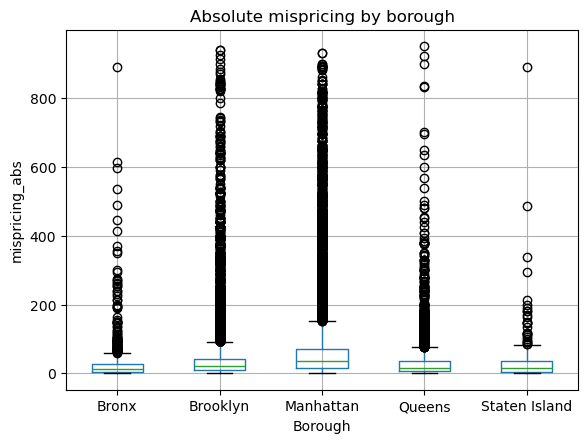

In [228]:
df.boxplot(column="mispricing_abs", by="neighbourhood_group")
plt.title("Absolute mispricing by borough")
plt.suptitle("")
plt.xlabel("Borough")
plt.ylabel("mispricing_abs")
plt.show()

Figure 3 compares the distribution of mispricing_abs across boroughs. Medians differ by borough and all boroughs exhibit heavy upper tails, indicating that location-level factors matter for pricing deviations even after benchmarking within neighbourhood × room_type. This motivates including broad location controls (e.g., borough indicators and borough-level covariates such as crime).

# Project 2

## 2.1 The Message

Listings with higher reviews_per_month exhibit lower mispricing_abs on average, but the size of that relationship is economically modest. The negative review–mispricing relationship is flatter in high-log_comp_density markets, suggesting that review-based learning is weaker—not stronger—where local price signals are already clearer.

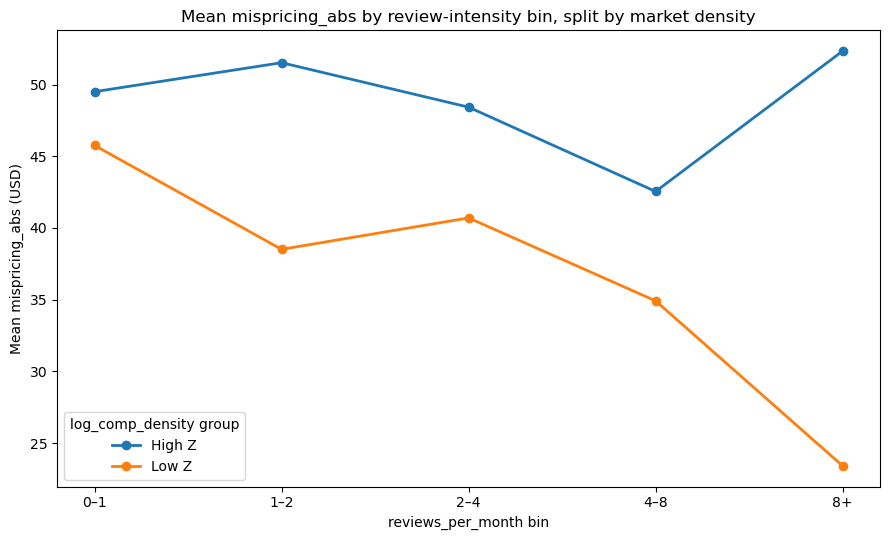

In [229]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the complete-case sample for the key message variables
msg_df = df[["mispricing_abs", "reviews_per_month", "log_comp_density"]].dropna().copy()

# Split markets by clarity of local price signals
msg_df["Z_group"] = np.where(
    msg_df["log_comp_density"] <= msg_df["log_comp_density"].median(),
    "Low Z",
    "High Z"
)

# Use broader review-intensity bins to reduce tail noise
bins = [0, 1, 2, 4, 8, np.inf]
labels = ["0–1", "1–2", "2–4", "4–8", "8+"]

msg_df["review_bin"] = pd.cut(
    msg_df["reviews_per_month"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Collapse to mean mispricing by review bin and market-density group
msg_plot = (
    msg_df.dropna(subset=["review_bin"])
    .groupby(["review_bin", "Z_group"], observed=True)
    .agg(
        mean_mispricing_abs=("mispricing_abs", "mean"),
        n=("mispricing_abs", "size")
    )
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(9, 5.5))

for group, sub in msg_plot.groupby("Z_group", sort=False):
    ax.plot(
        sub["review_bin"].astype(str),
        sub["mean_mispricing_abs"],
        marker="o",
        linewidth=2,
        label=group
    )

ax.set_title("Mean mispricing_abs by review-intensity bin, split by market density")
ax.set_xlabel("reviews_per_month bin")
ax.set_ylabel("Mean mispricing_abs (USD)")
ax.legend(title="log_comp_density group")
plt.tight_layout()
plt.show()

This figure plots mean mispricing_abs (in dollars) against binned reviews_per_month, separately for Low Z and High Z markets, where Z is a median split of log_comp_density. Using the complete-case sample with non-missing mispricing_abs, reviews_per_month, and log_comp_density, the plot shows that average pricing inefficiency generally declines as review intensity rises, which supports the message that listings with more ongoing feedback tend to be priced closer to the neighbourhood × room_type benchmark. At the same time, the gap between Low Z and High Z markets does not widen in the way originally hypothesized; if anything, the decline appears flatter in denser markets, which is consistent with the regression result that the review–mispricing relationship is weaker rather than stronger when log_comp_density is higher.

## 2.2  Maps and Interpretations

In [230]:
import geopandas as gpd

# Load MODZCTA polygons
modzcta = gpd.read_file("../MODZCTA_2010_WGS1984.geo.json")

# Make sure CRS matches the listing points
modzcta = modzcta.to_crs("EPSG:4326")

# Convert df to listing points if needed
airbnb_points = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# Spatial join: assign each listing to a MODZCTA
df_modzcta = gpd.sjoin(
    airbnb_points,
    modzcta,
    how="left",
    predicate="within"
)


In [231]:
zip_map_df = (
    df_modzcta
    .dropna(subset=["MODZCTA"])
    .groupby("MODZCTA", as_index=False)
    .agg(
        mean_mispricing_abs=("mispricing_abs", "mean"),
        mean_reviews_per_month=("reviews_per_month", "mean"),
        mean_log_comp_density=("log_comp_density", "mean"),
        mean_nearest_subway_km=("nearest_subway_km", "mean"),
        n_listings=("id", "count")
    )
)


In [232]:
modzcta_map = modzcta.merge(zip_map_df, on="MODZCTA", how="left")

map_gdf = modzcta_map.copy()
map_gdf = map_gdf[map_gdf["n_listings"] >= 20].copy()

In [233]:
import matplotlib.pyplot as plt

map_gdf = modzcta_map.copy()
map_gdf = map_gdf[map_gdf["n_listings"] >= 20].copy()


In [234]:
def make_map(gdf, column, title, cmap="viridis", filename=None):
    fig, ax = plt.subplots(figsize=(10, 10))

    gdf.plot(
        column=column,
        ax=ax,
        legend=True,
        cmap=cmap,
        linewidth=0.2,
        edgecolor="white",
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "white",
            "hatch": "///",
            "label": "No data"
        }
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.axis("off")
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

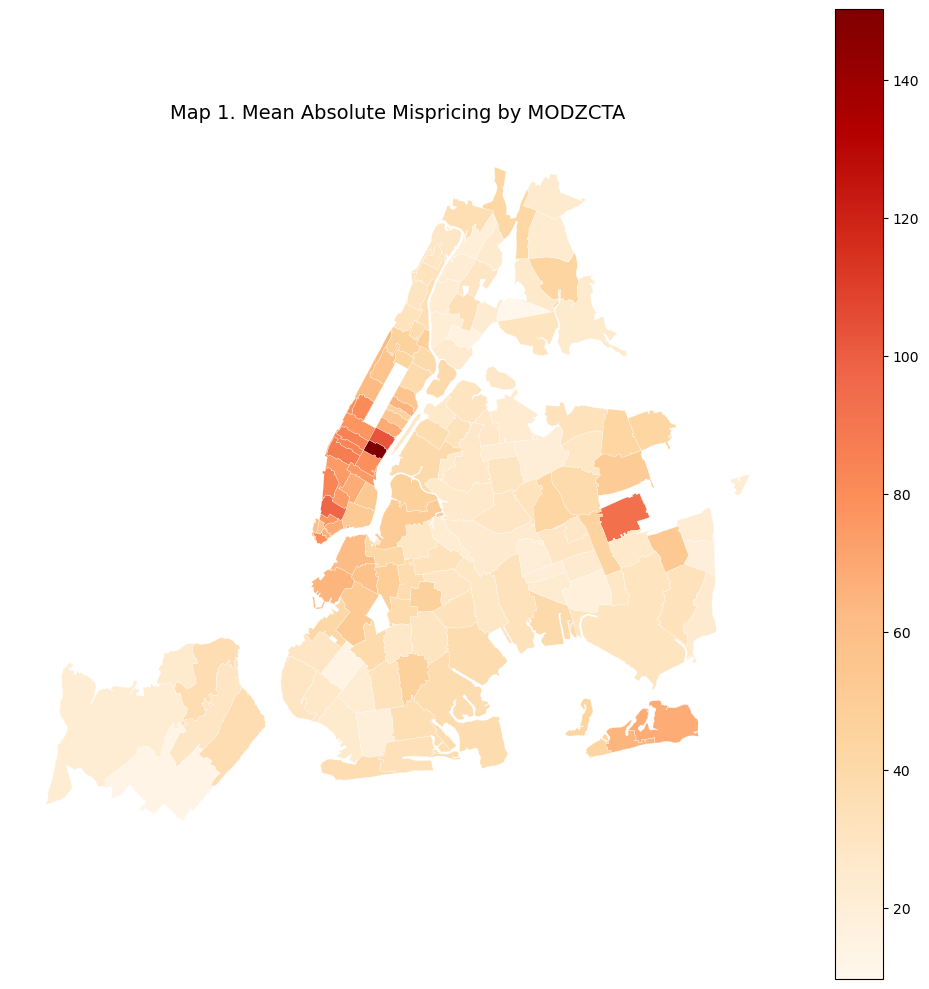

In [235]:
make_map(
    map_gdf,
    column="mean_mispricing_abs",
    title="Map 1. Mean Absolute Mispricing by MODZCTA",
    cmap="OrRd",
    filename="map1_mean_mispricing_abs.png"
)

Map 1 shows clear spatial heterogeneity in mean absolute mispricing across New York City. Higher average mispricing appears in parts of Manhattan, along with a few more isolated pockets in the outer boroughs, while many MODZCTAs in Brooklyn, Queens, and Staten Island display lower average deviations from the neighbourhood × room_type benchmark. This suggests that pricing inefficiency is not evenly distributed across space and may be shaped by local market conditions rather than by listing-level characteristics alone.

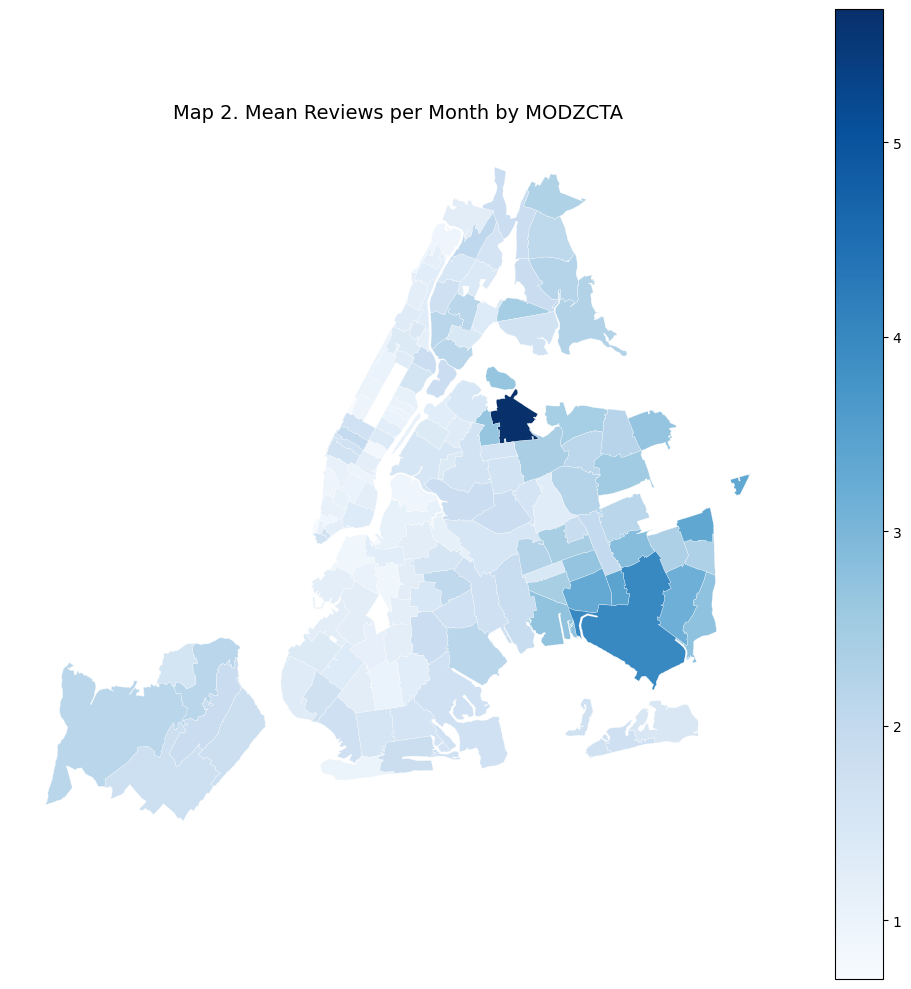

In [236]:
make_map(
    map_gdf,
    column="mean_reviews_per_month",
    title="Map 2. Mean Reviews per Month by MODZCTA",
    cmap="Blues",
    filename="map2_mean_reviews_per_month.png"
)

Map 2 indicates that review intensity also varies across space, although its pattern is less concentrated than the pattern for comparable-listing density. Some MODZCTAs in Queens and other selected parts of the city show relatively high average reviews per month, while many Manhattan and Brooklyn areas appear more moderate. This suggests that market feedback, as proxied by review intensity, is unevenly distributed across the city and does not map perfectly onto the areas with the highest mispricing.

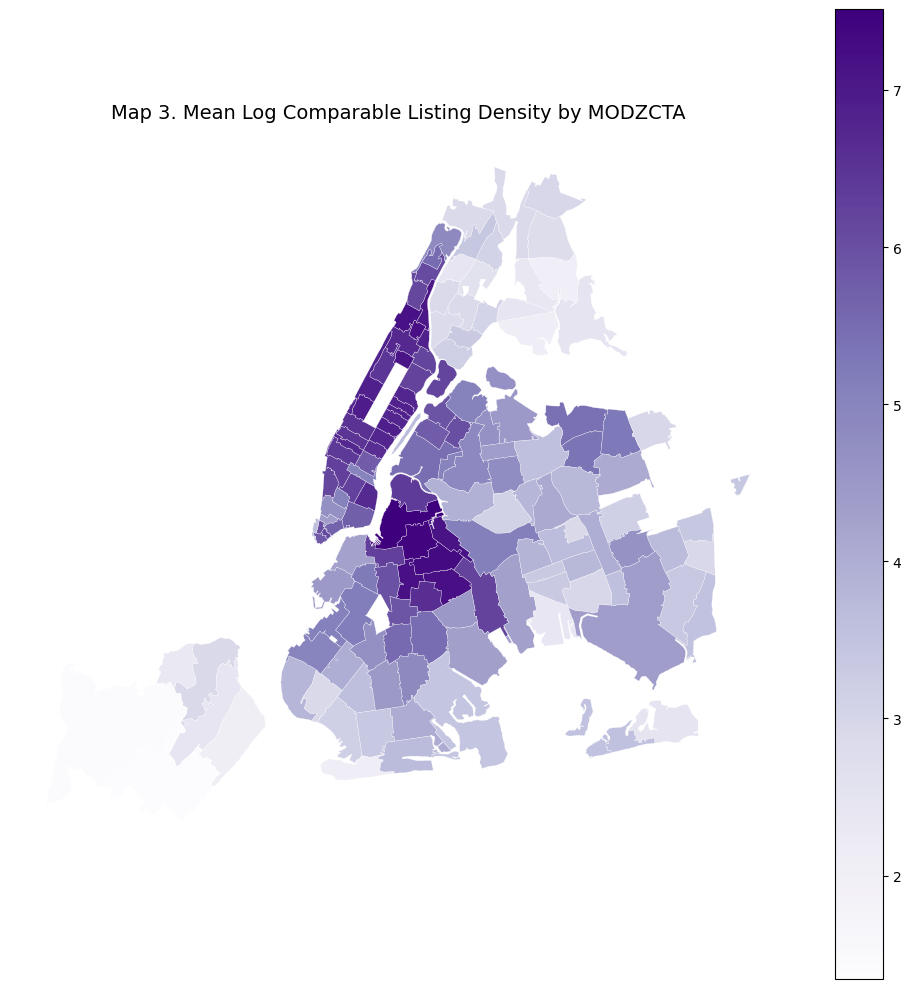

In [237]:
make_map(
    map_gdf,
    column="mean_log_comp_density",
    title="Map 3. Mean Log Comparable Listing Density by MODZCTA",
    cmap="Purples",
    filename="map3_mean_log_comp_density.png"
)

Map 3 displays the clearest spatial pattern of the four maps. Comparable-listing density is highest in Manhattan and in parts of central Brooklyn, while it is substantially lower in Staten Island and in more peripheral sections of Queens and the Bronx. This is consistent with the idea that denser urban-core markets provide clearer local price signals, since hosts in those areas face a larger number of similar nearby listings from which to infer a going rate.

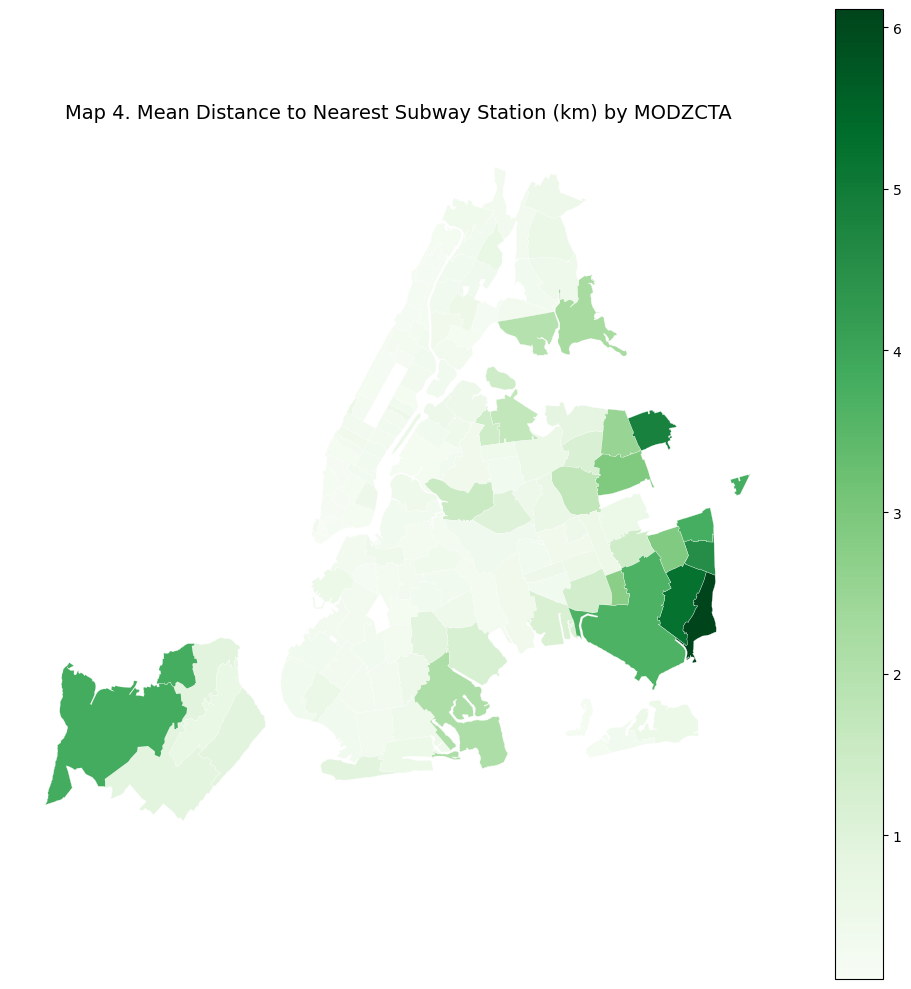

In [238]:
make_map(
    map_gdf,
    column="mean_nearest_subway_km",
    title="Map 4. Mean Distance to Nearest Subway Station (km) by MODZCTA",
    cmap="Greens",
    filename="map4_mean_nearest_subway_km.png"
)

Map 4 shows that distance to the nearest subway station is lowest in much of Manhattan and the inner-city core, and highest in Staten Island and farther-out parts of Queens. In other words, transit access is strongest in the dense central parts of the city and weakest in more peripheral areas. This pattern is broadly consistent with the idea that transit accessibility is another important spatial dimension of local market conditions, since areas farther from subway access may face different demand conditions and pricing environments.

Overall comparison across maps
Taken together, the four maps suggest that Airbnb pricing inefficiency, review intensity, comparable-market density, and transit accessibility all vary meaningfully across space, but they do not move one-for-one. The strongest and most intuitive spatial patterns appear in comparable-listing density and subway access, both of which are concentrated in the urban core. By contrast, the relationship between review intensity and mispricing appears more mixed geographically, which suggests that the review–mispricing relationship is unlikely to be explained by simple visual overlap alone. This spatial heterogeneity helps motivate the regression analysis, which can more directly test whether higher review intensity is associated with lower pricing inefficiency after accounting for market density, transit access, and other controls.

## 2.3 Regressions

In [239]:
# Regressions: benchmark + 8 models

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display, HTML
from stargazer.stargazer import Stargazer

# Start from one row per listing

reg_df = df.sort_values("id").drop_duplicates(subset="id", keep="first").copy()

# Create transformed variables for nonlinear specs
reg_df["log_reviews_pm"] = np.log1p(reg_df["reviews_per_month"])
reg_df["reviews_pm_sq"] = reg_df["reviews_per_month"] ** 2
reg_df["log_mispricing_abs"] = np.log1p(reg_df["mispricing_abs"])

# Use one common regression sample so N is comparable across models
reg_vars = [
    "id",
    "mispricing_abs",
    "log_mispricing_abs",
    "reviews_per_month",
    "log_reviews_pm",
    "reviews_pm_sq",
    "log_comp_density",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "calculated_host_listings_count",
    "crime_total_2019",
    "log_nearest_subway_km"
]

reg_df = reg_df[reg_vars].dropna().copy()


# Helper function for running OLS with robust standard errors
def fit_ols(formula, data):
    return smf.ols(formula=formula, data=data).fit(cov_type="HC1")


# FORMULAS


# Benchmark only 
f_bench = "mispricing_abs ~ reviews_per_month"

# Table 1: core linear sequence (4 regressions)
f1 = """
mispricing_abs ~ reviews_per_month + log_comp_density + minimum_nights
"""

f2 = """
mispricing_abs ~ reviews_per_month + log_comp_density + minimum_nights
                + availability_365
"""

f3 = """
mispricing_abs ~ reviews_per_month + log_comp_density + minimum_nights
                + availability_365 + number_of_reviews
"""

f4 = """
mispricing_abs ~ reviews_per_month + log_comp_density + minimum_nights
                + availability_365 + number_of_reviews
                + calculated_host_listings_count + crime_total_2019
"""

# Table 2: interaction / nonlinear / robustness (4 regressions)
f5 = """
mispricing_abs ~ reviews_per_month * log_comp_density
                + minimum_nights + availability_365 + number_of_reviews
                + calculated_host_listings_count + crime_total_2019
                + log_nearest_subway_km
"""

f6 = """
mispricing_abs ~ log_reviews_pm + log_comp_density
                + minimum_nights + availability_365 + number_of_reviews
                + calculated_host_listings_count + crime_total_2019
                + log_nearest_subway_km
"""

f7 = """
mispricing_abs ~ reviews_per_month + reviews_pm_sq + log_comp_density
                + minimum_nights + availability_365 + number_of_reviews
                + calculated_host_listings_count + crime_total_2019
                + log_nearest_subway_km
"""

f8 = """
log_mispricing_abs ~ log_reviews_pm + log_comp_density
                    + minimum_nights + availability_365 + number_of_reviews
                    + calculated_host_listings_count + crime_total_2019
                    + log_nearest_subway_km
"""

# Fit the models
m_bench = fit_ols(f_bench, reg_df)

m1 = fit_ols(f1, reg_df)
m2 = fit_ols(f2, reg_df)
m3 = fit_ols(f3, reg_df)
m4 = fit_ols(f4, reg_df)

m5 = fit_ols(f5, reg_df)
m6 = fit_ols(f6, reg_df)
m7 = fit_ols(f7, reg_df)
m8 = fit_ols(f8, reg_df)


# TABLE 1


stargazer1 = Stargazer([m_bench, m1, m2, m3, m4])
stargazer1.title("Table 3. OLS Regressions: Core Linear Specifications")
stargazer1.custom_columns(["Benchmark", "R1", "R2", "R3", "R4"], [1, 1, 1, 1, 1])
stargazer1.show_model_numbers(False)
stargazer1.rename_covariates({
    "Intercept": "Constant",
    "reviews_per_month": "Reviews per month",
    "log_comp_density": "Log comparable density",
    "minimum_nights": "Minimum nights",
    "availability_365": "Availability 365",
    "number_of_reviews": "Number of reviews",
    "calculated_host_listings_count": "Host listings count",
    "crime_total_2019": "Crime total (2019)"
})
stargazer1.add_line("Crime control", ["No", "No", "No", "No", "Yes"])
stargazer1.add_line("Transit control", ["No", "No", "No", "No", "No"])
stargazer1.add_line("Interaction included", ["No", "No", "No", "No", "No"])
stargazer1.add_line("Transformed X/Y", ["No", "No", "No", "No", "No"])

display(HTML(stargazer1.render_html()))


# TABLE 2


stargazer2 = Stargazer([m5, m6, m7, m8])
stargazer2.title("Table 4. OLS Regressions: Interaction, Nonlinearity, and Robustness")
stargazer2.custom_columns(["R5", "R6", "R7", "R8"], [1, 1, 1, 1])
stargazer2.show_model_numbers(False)
stargazer2.rename_covariates({
    "Intercept": "Constant",
    "reviews_per_month": "Reviews per month",
    "reviews_pm_sq": "Reviews per month squared",
    "log_reviews_pm": "Log(1 + reviews/month)",
    "log_comp_density": "Log comparable density",
    "reviews_per_month:log_comp_density": "Reviews × log density",
    "log_reviews_pm:log_comp_density": "Log reviews × log density",
    "minimum_nights": "Minimum nights",
    "availability_365": "Availability 365",
    "number_of_reviews": "Number of reviews",
    "calculated_host_listings_count": "Host listings count",
    "crime_total_2019": "Crime total (2019)",
    "log_nearest_subway_km": "Log distance to subway (km)",
})
stargazer2.add_line("Crime control", ["Yes", "Yes", "Yes", "Yes"])
stargazer2.add_line("Transit control", ["Yes", "Yes", "Yes", "Yes"])
stargazer2.add_line("Interaction included", ["Yes", "No", "No", "No"])
stargazer2.add_line("Transformed X/Y", ["No", "X only", "Quadratic X", "X and Y"])

display(HTML(stargazer2.render_html()))

**Regression interpretation**: Table 3 shows a consistent negative association between review intensity and pricing inefficiency. Across the benchmark and core linear specifications, the coefficient on reviews_per_month remains negative and statistically significant, even after adding log_comp_density, listing controls, host controls, and the borough-level crime control. In substantive terms, the estimates imply that one additional review per month is associated with roughly 0.85 to 2.66 dollars lower absolute mispricing, depending on specification. This suggests that review activity is linked to modest but meaningful improvements in pricing efficiency, measured as smaller deviations from the neighbourhood × room_type benchmark price. At the same time, the low R-squared values indicate that reviews explain only a small share of the total variation in mispricing, which is consistent with the idea that Airbnb pricing is also shaped by many listing-specific and unobserved factors.

Table 4 adds interaction, nonlinearity, and robustness checks. The most notable result is that the interaction between reviews_per_month and log_comp_density is positive and statistically significant, which goes against the original hypothesis that clearer local price signals would strengthen the review-based learning effect. Instead, the negative association between reviews and mispricing appears to become weaker in denser comparable markets. Using the interaction estimates, the implied effect of one additional review per month is about 0.83 dollars lower absolute mispricing in lower-density markets, but only about 0.19 dollars lower absolute mispricing in higher-density markets. The logged-review specification still produces a negative and significant coefficient, which is more consistent with a diminishing-returns interpretation: the first additional reviews appear to provide more useful pricing feedback than later ones. In that specification, doubling reviews per month is associated with roughly 1.7 dollars lower absolute mispricing. By contrast, the quadratic term on reviews is small and statistically weak, so the evidence for a simple polynomial nonlinearity is limited.

Taken together, the regression results suggest that Airbnb reviews do appear to help hosts price more efficiently, but the extent of that relationship is economically modest and depends on market context. In level terms, the effect is generally small, amounting to about 1 to 3 dollars less absolute mispricing per additional review per month in the simpler linear models and less than 1 dollar in the fuller controlled specifications. In proportional terms, the log-log robustness model implies that a 10 percent increase in reviews per month is associated with about a 1 percent decrease in absolute mispricing, while doubling review intensity is associated with about a 6.7 percent decrease in mispricing. A reasonable summary, then, is that more reviews are associated with lower mispricing on average, but the size of that effect is fairly modest and does not become stronger in denser markets. This means the paper’s main finding is supported, while the proposed mechanism is not: review activity is linked to lower pricing inefficiency, but comparable-listing density does not seem to amplify that relationship.

## 2.4 Conclusion
This project examined whether greater Airbnb review intensity is associated with lower pricing inefficiency in New York City listings. Using mispricing_abs as the absolute deviation from the neighbourhood × room_type benchmark price, the descriptive figures, maps, and OLS regressions all point to the same broad conclusion: listings with higher reviews_per_month tend to be priced closer to their local benchmark on average. In the regression analysis, this relationship remains negative and statistically significant across the core specifications, suggesting that review activity is associated with modest but meaningful improvements in pricing efficiency.
The regression results also help answer the question of extent. Across the core linear models, one additional review per month is associated with roughly 0.85 to 2.66 dollars lower absolute mispricing, depending on the specification. This implies that the effect is economically modest rather than dramatic: review activity appears to help hosts move closer to the local benchmark, but it explains only a limited share of total pricing variation. The low R-squared values reinforce this interpretation, indicating that Airbnb pricing inefficiency is influenced by many other listing-specific and unobserved factors beyond review activity alone.
The nonlinear specifications point in the same direction. In the logged-review model, doubling reviews_per_month is associated with roughly 1.7 dollars lower absolute mispricing, while the log-log specification implies that a 10 percent increase in review intensity is associated with about a 1 percent decrease in absolute mispricing, and doubling review intensity is associated with about a 6.7 percent decrease in mispricing. The mechanism results are more mixed. The original expectation was that the review–mispricing relationship would be stronger in markets with clearer local price signals, proxied by log_comp_density. However, the positive and statistically significant interaction between reviews_per_month and log_comp_density suggests the opposite: the negative association between reviews and mispricing becomes weaker in denser comparable markets. In other words, while review activity is consistently associated with lower pricing inefficiency, comparable-listing density does not appear to amplify that relationship in the way initially hypothesized.
The spatial analysis provides useful context for these results. The maps show strong geographic heterogeneity in mispricing, review activity, comparable-listing density, and transit access across NYC MODZCTAs. Comparable density and subway access are most concentrated in the urban core, while review intensity and mispricing display a more uneven spatial pattern. These maps suggest that local market structure and accessibility matter for understanding where pricing inefficiency is more or less pronounced, even though visual overlap alone is not enough to explain the full relationship.
There are several limitations to this analysis. First, the results are descriptive and should not be interpreted causally. Second, the dependent variable is constructed relative to neighbourhood × room_type medians, which is useful for defining local pricing inefficiency but may still omit relevant quality differences across listings. Third, some spatial controls, such as borough-level crime, remain fairly coarse. Future work could improve on this by incorporating richer listing amenities, more granular neighbourhood controls, stronger measures of local demand, and potentially causal designs or machine-learning methods in the final project.
Overall, the evidence suggests that more frequent review activity is associated with lower Airbnb pricing inefficiency in NYC, but the magnitude of that relationship is modest and varies across market environments. The main finding of the paper is therefore supported, while the proposed market-density mechanism is not. This provides a strong base for the final project, where the next step will be to compare these regression-based findings with more flexible predictive approaches and assess whether nonlinear methods improve explanatory performance.



## References
Abrate, G., Sainaghi, R., & Mauri, A. G. (2022). Dynamic pricing in Airbnb: Individual versus professional hosts. Journal of Business Research, 142, 191–199. https://doi.org/10.1016/j.jbusres.2021.12.012


Bárcena-Martín, E., Benítez-Aurioles, B., & Pérez-Moreno, S. (2023). Peer-to-peer accommodation prices: City listing concentration and host listing share. *Tourism Economics, 29*(6), 1499–1519. https://doi.org/10.1177/13548166221110526


Bernardi, M., & Guidolin, M. (2023). The determinants of Airbnb prices in New York City: A spatial quantile regression approach. Journal of the Royal Statistical Society: Series C (Applied Statistics), 72(1), 106–143. https://doi.org/10.1093/jrsssc/qlad001


Boto-García, D., Mayor, M., & De la Vega, P. (2021). Spatial price mimicking on Airbnb: Multi-host vs single-host. *Tourism Management, 87*, Article 104365. https://doi.org/10.1016/j.tourman.2021.104365


Ert, E., Fleischer, A., & Magen, N. (2016). Trust and reputation in the sharing economy: The role of personal photos in Airbnb. Tourism Management, 55, 62–73. https://doi.org/10.1016/j.tourman.2016.01.013


Gyódi, K., & Nawaro, Ł. (2021). Determinants of Airbnb prices in European cities: A spatial econometrics approach. *Tourism Management, 86*, Article 104319. https://doi.org/10.1016/j.tourman.2021.104319


Lawani, A., Reed, M. R., Mark, T., & Zheng, Y. (2019). Reviews and price on online platforms: Evidence from sentiment analysis of Airbnb reviews in Boston. *Regional Science and Urban Economics, 75*, 22–34. https://doi.org/10.1016/j.regsciurbeco.2018.11.003


Lin, W., & Yang, F. (2024). The price of short-term housing: A study of Airbnb on 26 regions in the United States. *Journal of Housing Economics, 65*, Article 102005. https://doi.org/10.1016/j.jhe.2024.102005


Mayya, R., Ye, S., Viswanathan, S., & Agarwal, R. (2021). Who forgoes screening in online markets and why? Evidence from Airbnb. MIS Quarterly, 45(4), 1745–1776. https://doi.org/10.25300/MISQ/2021/15335

Proserpio, D., Xu, W., & Zervas, G. (2018). You get what you give: Theory and evidence of reciprocity in the sharing economy. *Quantitative Marketing and Economics, 16*(4), 371–407. https://doi.org/10.1007/s11129-018-9201-9


Voltes-Dorta, A. (2025). Price competition among short-term Airbnb listings in New York City following Local Law 18. Current Issues in Tourism, 28(13), 2047–2051. https://doi.org/10.1080/13683500.2024.2354521


Zhao, H. (2023). Influence of built environment features on Airbnb listing price and the spatio-temporal heterogeneity: An empirical study from Copenhagen, Denmark. Geografisk Tidsskrift-Danish Journal of Geography, 123(1), 42–60. https://doi.org/10.1080/00167223.2023.2275037

dgomonov. (2019). New York City Airbnb Open Data [Data set]. Kaggle. Retrieved January 23, 2026, from https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data


New York City Police Department. (n.d.). NYPD Complaint Data Historic [Data set]. NYC Open Data (via data.gov). Retrieved January 30, 2026, from https://catalog.data.gov/dataset/nypd-complaint-data-historic


NYC Environment and Health Data Portal. (n.d.). MODZCTA_2010_WGS1984.geo.json [GeoJSON file]. GitHub. Retrieved March 13, 2026, from https://github.com/nycehs/NYC_geography/blob/master/MODZCTA_2010_WGS1984.geo.json


Metropolitan Transportation Authority. (n.d.). MTA Subway Stations and Complexes [Data set]. Open NY. Retrieved March 13, 2026, from https://data.ny.gov/Transportation/MTA-Subway-Stations-and-Complexes/5f5g-n3cz